<a href="https://colab.research.google.com/github/meenakshi930/DiseaseLeafClassifier/blob/anshika-data/Anshika/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disease Leaf Classifier — Data Exploration

## Objective
Explore the crop leaf image dataset, understand its structure, identify the disease classes, examine the number of images in each class, and visualize sample images.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
!pip -q install kagglehub

In [3]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to:
/kaggle/input/plantdisease


In [4]:
import os

dataset_path = "/kaggle/input/plantdisease"

print("Dataset contents:")
print(os.listdir(dataset_path))

Dataset contents:
['PlantVillage', 'plantvillage']


In [5]:
for folder in ["PlantVillage", "plantvillage"]:
    folder_path = os.path.join(dataset_path, folder)
    print(f"\n{folder}:")
    print(os.listdir(folder_path)[:20])


PlantVillage:
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']

plantvillage:
['PlantVillage']


In [6]:
plantvillage_path = os.path.join(dataset_path, "PlantVillage")

classes = sorted(os.listdir(plantvillage_path))

print("Number of classes:", len(classes))
print("\nClasses:")
for i, class_name in enumerate(classes, 1):
    print(i, class_name)

Number of classes: 15

Classes:
1 Pepper__bell___Bacterial_spot
2 Pepper__bell___healthy
3 Potato___Early_blight
4 Potato___Late_blight
5 Potato___healthy
6 Tomato_Bacterial_spot
7 Tomato_Early_blight
8 Tomato_Late_blight
9 Tomato_Leaf_Mold
10 Tomato_Septoria_leaf_spot
11 Tomato_Spider_mites_Two_spotted_spider_mite
12 Tomato__Target_Spot
13 Tomato__Tomato_YellowLeaf__Curl_Virus
14 Tomato__Tomato_mosaic_virus
15 Tomato_healthy


In [7]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(plantvillage_path, class_name)
    image_count = len(os.listdir(class_path))
    class_counts[class_name] = image_count

print("Images in each class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Images in each class:

Pepper__bell___Bacterial_spot: 997
Pepper__bell___healthy: 1478
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1909
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209
Tomato__Tomato_mosaic_virus: 373
Tomato_healthy: 1591


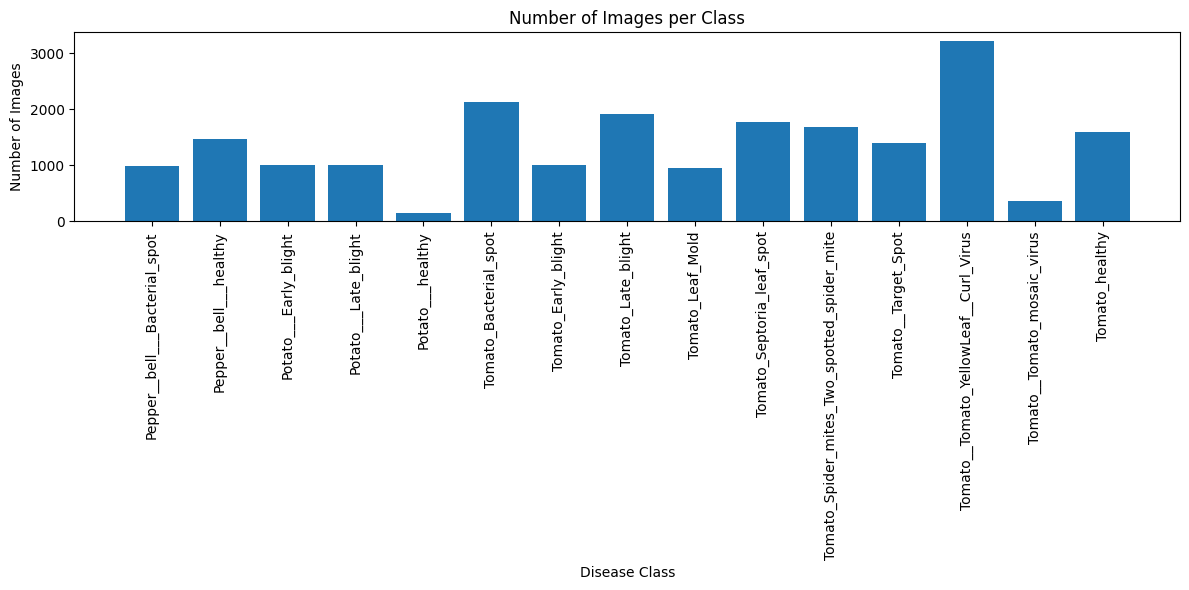

In [8]:
plt.figure(figsize=(12, 6))

plt.bar(class_counts.keys(), class_counts.values())

plt.xticks(rotation=90)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")

plt.tight_layout()
plt.show()

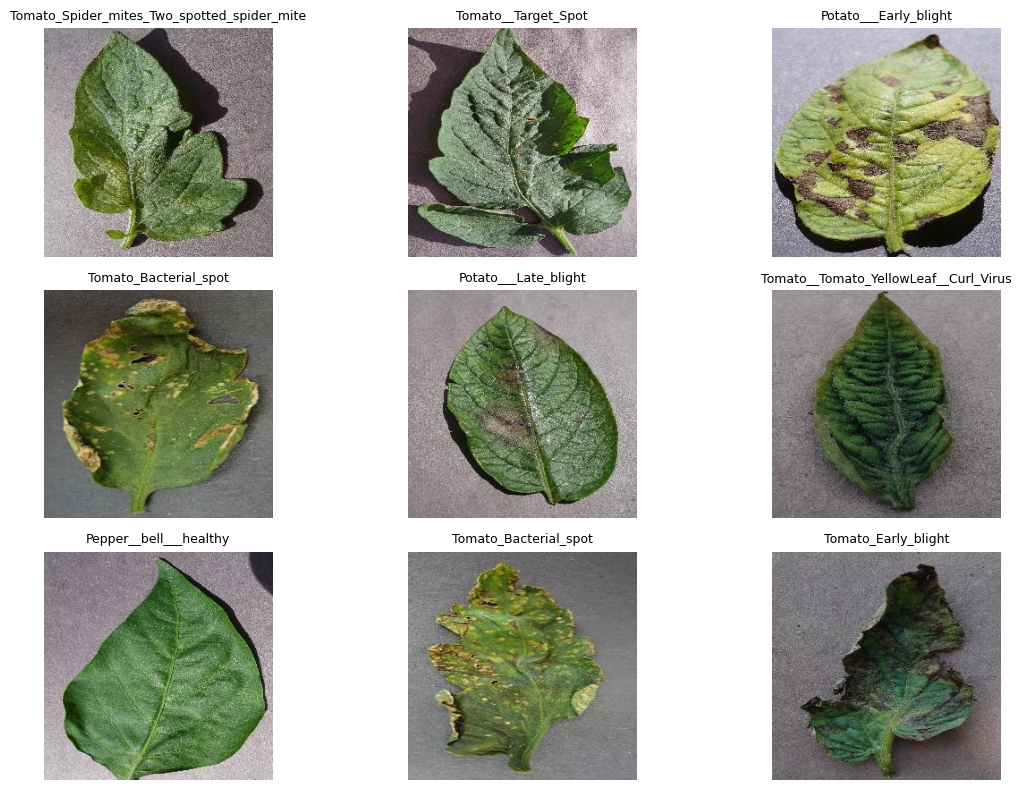

In [9]:
import random

plt.figure(figsize=(12, 8))

for i in range(9):
    class_name = random.choice(classes)
    class_path = os.path.join(plantvillage_path, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
from collections import Counter

size_counts = Counter()

for class_name in classes:
    class_path = os.path.join(plantvillage_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)
            size_counts[image.size] += 1
        except:
            pass

print("Image dimensions found:")
for size, count in size_counts.items():
    print(size, ":", count)

Image dimensions found:
(256, 256) : 20638


In [12]:
total_images = sum(class_counts.values())

print("Total number of images:", total_images)
print("Total number of classes:", len(classes))

Total number of images: 20639
Total number of classes: 15


In [13]:
invalid_files = []

for class_name in classes:
    class_path = os.path.join(plantvillage_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)
            image.verify()
        except:
            invalid_files.append((class_name, image_name))

print("Invalid/non-image files:", len(invalid_files))

for item in invalid_files:
    print(item)

Invalid/non-image files: 1
('Tomato__Tomato_YellowLeaf__Curl_Virus', 'svn-r6Yb5c')


In [14]:
for class_name, count in class_counts.items():
    percentage = (count / total_images) * 100
    print(f"{class_name}: {percentage:.2f}%")

Pepper__bell___Bacterial_spot: 4.83%
Pepper__bell___healthy: 7.16%
Potato___Early_blight: 4.85%
Potato___Late_blight: 4.85%
Potato___healthy: 0.74%
Tomato_Bacterial_spot: 10.31%
Tomato_Early_blight: 4.85%
Tomato_Late_blight: 9.25%
Tomato_Leaf_Mold: 4.61%
Tomato_Septoria_leaf_spot: 8.58%
Tomato_Spider_mites_Two_spotted_spider_mite: 8.12%
Tomato__Target_Spot: 6.80%
Tomato__Tomato_YellowLeaf__Curl_Virus: 15.55%
Tomato__Tomato_mosaic_virus: 1.81%
Tomato_healthy: 7.71%


## EDA Summary

The PlantVillage dataset used for this project contains 15 crop disease and healthy-leaf classes.

### Key Findings

- Total files: 20,639
- Valid images: 20,638
- Invalid/non-image files: 1
- Number of classes: 15
- Image size: 256 × 256 pixels
- Image format: RGB
- The dataset has an imbalanced class distribution.
- The largest class is Tomato Yellow Leaf Curl Virus.
- The smallest class is Potato healthy.
- Sample images show that the dataset mainly contains clearly visible leaves with relatively controlled backgrounds.

### Conclusion

The dataset is suitable for developing an initial crop disease classification model.
The class imbalance should be considered during preprocessing and model training.
The invalid file will be ignored during data loading.